# W03 Regression Model — Multivariate Linear Regression for Aido Rover Fault Status

## Problem Statement

This notebook applies multivariate linear regression to identify the strongest determinants of Aido Rover fault status.

The main question is:

**Which sensor variables are the strongest determinants of Aido Rover fault probability?**

This notebook follows the Tsinghua-style methodology:

1. Start with candidate predictors from EDA and correlation analysis.
2. Build multivariate OLS regression models.
3. Compare full, screened, and selected models.
4. Interpret coefficients.
5. Check residual diagnostics.
6. Explain the limitation of using OLS for a binary outcome.

## 1. Import Packages

In [2]:
# Optional install cell. Run only if needed.
# %pip install pandas matplotlib scipy statsmodels

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

## 2. Load Dataset

In [4]:
possible_paths = [
    Path("../data/synthetic_rover_data.csv"),
    Path("../data/synthetic rover data.csv"),
    Path("../../week1/data/synthetic_rover_data.csv"),
    Path("../../week1/data/synthetic rover data.csv"),
    Path("../../../week1/data/synthetic_rover_data.csv"),
    Path("../../../week1/data/synthetic rover data.csv"),
]

data_path = None

for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find the synthetic rover data CSV. "
        "Please check the file path and update possible_paths."
    )

print("Loaded data from:", data_path)

df = pd.read_csv(data_path)
df.head()

Loaded data from: ..\..\week1\data\synthetic_rover_data.csv


,timestamp,unit_id,gps_lat,gps_lon,lidar_dist,battery_soc,torque_fl,torque_fr,torque_rl,torque_rr,ambient_temp,fault_label
0,2026-06-22 00:00:00,ROVER_01,37.387102,-121.979485,3.286,72.46,7.899,9.458,9.574,10.687,26.02,0
1,2026-06-22 00:01:00,ROVER_18,37.392078,-121.958254,2.843,57.83,3.922,8.088,5.485,4.936,19.68,0
2,2026-06-22 00:02:00,ROVER_11,37.395329,-121.966144,3.569,59.29,10.364,9.169,10.114,10.455,23.05,0
3,2026-06-22 00:03:00,ROVER_20,37.394625,-121.978246,3.284,70.02,5.074,10.203,6.993,8.247,20.36,0
4,2026-06-22 00:04:00,ROVER_12,37.392388,-121.964007,1.909,56.78,9.004,8.305,8.141,9.586,29.57,0


## 3. Feature Engineering

The four wheel torque variables may be strongly correlated with each other. To reduce multicollinearity, this notebook creates two engineered features:

- `torque_mean`: average torque across all four wheels
- `torque_std`: row-level torque variation across the four wheels

In [5]:
torque_cols = ["torque_fl", "torque_fr", "torque_rl", "torque_rr"]

df["torque_mean"] = df[torque_cols].mean(axis=1)
df["torque_std"] = df[torque_cols].std(axis=1)

df[["torque_fl", "torque_fr", "torque_rl", "torque_rr", "torque_mean", "torque_std"]].head()

,torque_fl,torque_fr,torque_rl,torque_rr,torque_mean,torque_std
0,7.899,9.458,9.574,10.687,9.40450,1.146433
1,3.922,8.088,5.485,4.936,5.60775,1.775735
2,10.364,9.169,10.114,10.455,10.02550,0.588919
3,5.074,10.203,6.993,8.247,7.62925,2.155607
4,9.004,8.305,8.141,9.586,8.75900,0.666332


## 4. Define Target and Predictor Sets

In [6]:
target = "fault_label"

original_sensor_features = [
    "gps_lat",
    "gps_lon",
    "lidar_dist",
    "battery_soc",
    "torque_fl",
    "torque_fr",
    "torque_rl",
    "torque_rr",
    "ambient_temp"
]

engineered_features = [
    "gps_lat",
    "gps_lon",
    "lidar_dist",
    "battery_soc",
    "torque_mean",
    "torque_std",
    "ambient_temp"
]

y = df[target]

## 5. Correlation Screening

This repeats the correlation screening step so the regression notebook is self-contained.

In [7]:
correlation_results = []

for col in engineered_features:
    r, p_value = stats.pearsonr(df[col], y)
    correlation_results.append({
        "feature": col,
        "pearson_r": r,
        "abs_r": abs(r),
        "p_value": p_value
    })

corr_table = pd.DataFrame(correlation_results)
corr_table = corr_table.sort_values("abs_r", ascending=False).reset_index(drop=True)

corr_table

,feature,pearson_r,abs_r,p_value
0,torque_mean,0.586944,0.586944,0.000000
1,battery_soc,-0.559559,0.559559,0.000000
2,lidar_dist,0.448805,0.448805,0.000000
3,torque_std,-0.012064,0.012064,0.139548
4,ambient_temp,-0.008346,0.008346,0.306704
5,gps_lat,-0.003060,0.003060,0.707842
6,gps_lon,0.000708,0.000708,0.930919


In [8]:
screened_features = corr_table[
    (corr_table["abs_r"] > 0.10) & (corr_table["p_value"] < 0.05)
]["feature"].tolist()

print("Correlation-screened features:")
screened_features

Correlation-screened features:


['torque_mean', 'battery_soc', 'lidar_dist']

## 6. Helper Functions for OLS Regression

The model uses standardized predictors so coefficient magnitudes can be compared directly.

In [9]:
def standardize_features(data, features):
    X = data[features].copy()
    X_standardized = (X - X.mean()) / X.std(ddof=0)
    return X_standardized

def fit_ols_model(data, features, target_col="fault_label"):
    X = standardize_features(data, features)
    X = sm.add_constant(X)
    y = data[target_col]
    model = sm.OLS(y, X).fit()
    return model

def model_summary_table(model):
    summary = pd.DataFrame({
        "coefficient": model.params,
        "std_error": model.bse,
        "t_stat": model.tvalues,
        "p_value": model.pvalues
    })
    return summary.round(5)

## 7. Model 1 — Full Original Sensor Model

This model uses all original sensor variables. It is useful as a baseline, but torque variables may be multicollinear.

In [10]:
model_full = fit_ols_model(df, original_sensor_features)

print(model_full.summary())
model_summary_table(model_full)

                            OLS Regression Results                            
Dep. Variable:            fault_label   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     2042.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:30:53   Log-Likelihood:                 1359.8
No. Observations:               15000   AIC:                            -2700.
Df Residuals:                   14990   BIC:                            -2623.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1241      0.002     68.770   

,coefficient,std_error,t_stat,p_value
const,0.12413,0.00181,68.76975,0.00000
gps_lat,-0.00082,0.00181,-0.45387,0.64993
gps_lon,0.00117,0.00181,0.64538,0.51869
lidar_dist,0.08351,0.00190,43.91676,0.00000
battery_soc,-0.11944,0.00195,-61.31863,0.00000
torque_fl,0.02970,0.00488,6.09091,0.00000
torque_fr,0.04605,0.00486,9.48049,0.00000
torque_rl,0.02713,0.00484,5.60062,0.00000
torque_rr,0.03418,0.00489,6.99164,0.00000
ambient_temp,-0.00026,0.00181,-0.14399,0.88551


## 8. Model 2 — Correlation-Screened Engineered Model

This model uses only features that passed correlation screening.

In [11]:
if len(screened_features) == 0:
    raise ValueError("No features passed correlation screening. Lower the threshold or inspect the data.")

model_screened = fit_ols_model(df, screened_features)

print(model_screened.summary())
model_summary_table(model_screened)

                            OLS Regression Results                            
Dep. Variable:            fault_label   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     6123.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:30:53   Log-Likelihood:                 1356.1
No. Observations:               15000   AIC:                            -2704.
Df Residuals:                   14996   BIC:                            -2674.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1241      0.002     68.766      

,coefficient,std_error,t_stat,p_value
const,0.12413,0.00181,68.76622,0.0
torque_mean,0.13160,0.00195,67.36213,0.0
battery_soc,-0.11942,0.00195,-61.31288,0.0
lidar_dist,0.08349,0.00190,43.90997,0.0


## 9. Model 3 — Final Selected Model

This model starts from the screened feature list and removes predictors with p-value above 0.05 until all remaining predictors are statistically significant.

In [12]:
def backward_select(data, features, target_col="fault_label", p_threshold=0.05):
    selected = features.copy()

    while len(selected) > 1:
        model = fit_ols_model(data, selected, target_col)
        pvalues = model.pvalues.drop("const")
        max_p = pvalues.max()

        if max_p <= p_threshold:
            break

        feature_to_remove = pvalues.idxmax()
        print(f"Removing {feature_to_remove} with p-value {max_p:.5f}")
        selected.remove(feature_to_remove)

    final_model = fit_ols_model(data, selected, target_col)
    return selected, final_model

selected_features, model_final = backward_select(df, screened_features)

print("Final selected features:", selected_features)
print(model_final.summary())

model_summary_table(model_final)

Final selected features: ['torque_mean', 'battery_soc', 'lidar_dist']
                            OLS Regression Results                            
Dep. Variable:            fault_label   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     6123.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:30:53   Log-Likelihood:                 1356.1
No. Observations:               15000   AIC:                            -2704.
Df Residuals:                   14996   BIC:                            -2674.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

,coefficient,std_error,t_stat,p_value
const,0.12413,0.00181,68.76622,0.0
torque_mean,0.13160,0.00195,67.36213,0.0
battery_soc,-0.11942,0.00195,-61.31288,0.0
lidar_dist,0.08349,0.00190,43.90997,0.0


## 10. Model Comparison

In [13]:
model_comparison = pd.DataFrame([
    {
        "model": "Full Original Sensor Model",
        "features": len(original_sensor_features),
        "r_squared": model_full.rsquared,
        "adj_r_squared": model_full.rsquared_adj,
        "f_statistic": model_full.fvalue,
        "f_p_value": model_full.f_pvalue
    },
    {
        "model": "Correlation-Screened Engineered Model",
        "features": len(screened_features),
        "r_squared": model_screened.rsquared,
        "adj_r_squared": model_screened.rsquared_adj,
        "f_statistic": model_screened.fvalue,
        "f_p_value": model_screened.f_pvalue
    },
    {
        "model": "Final Selected Model",
        "features": len(selected_features),
        "r_squared": model_final.rsquared,
        "adj_r_squared": model_final.rsquared_adj,
        "f_statistic": model_final.fvalue,
        "f_p_value": model_final.f_pvalue
    }
])

model_comparison.round(5)

,model,features,r_squared,adj_r_squared,f_statistic,f_p_value
0,Full Original Sensor Model,9,0.55078,0.55051,2042.12226,0.0
1,Correlation-Screened Engineered Model,3,0.55056,0.55047,6123.22571,0.0
2,Final Selected Model,3,0.55056,0.55047,6123.22571,0.0


## 11. Top Determinants of Fault Status

Because predictors were standardized before regression, larger absolute coefficients indicate stronger determinants.

In [14]:
coef_table = model_summary_table(model_final)
coef_table = coef_table.drop(index="const", errors="ignore")
coef_table["abs_coefficient"] = coef_table["coefficient"].abs()

top_determinants = coef_table.sort_values("abs_coefficient", ascending=False)

top_determinants

,coefficient,std_error,t_stat,p_value,abs_coefficient
torque_mean,0.13160,0.00195,67.36213,0.0,0.13160
battery_soc,-0.11942,0.00195,-61.31288,0.0,0.11942
lidar_dist,0.08349,0.00190,43.90997,0.0,0.08349


In [15]:
print("Top 3 determinants:")
display(top_determinants.head(3))

Top 3 determinants:


,coefficient,std_error,t_stat,p_value,abs_coefficient
torque_mean,0.13160,0.00195,67.36213,0.0,0.13160
battery_soc,-0.11942,0.00195,-61.31288,0.0,0.11942
lidar_dist,0.08349,0.00190,43.90997,0.0,0.08349


## 12. Plain-English Coefficient Interpretation

Use the table above to write a short interpretation.

Example format:

- A negative `battery_soc` coefficient means higher battery state of charge is associated with lower fault probability.
- A positive `lidar_dist` coefficient means higher LiDAR distance values are associated with higher fault probability.
- A positive `torque_mean` coefficient means higher average wheel torque is associated with higher fault probability.

Because this is a linear probability model, coefficients can be interpreted as approximate changes in fault probability for a 1-standard-deviation increase in the predictor.

## 13. Residual Diagnostics

The internship plan requires residual diagnostics for the OLS model:

1. Residuals vs. fitted values plot
2. Q-Q plot
3. Scale-location plot

Because the target variable is binary, residuals will not be perfectly normal. This limitation should be stated clearly in the statistical report.

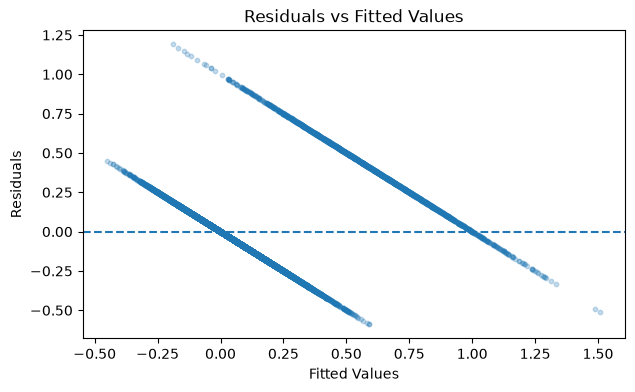

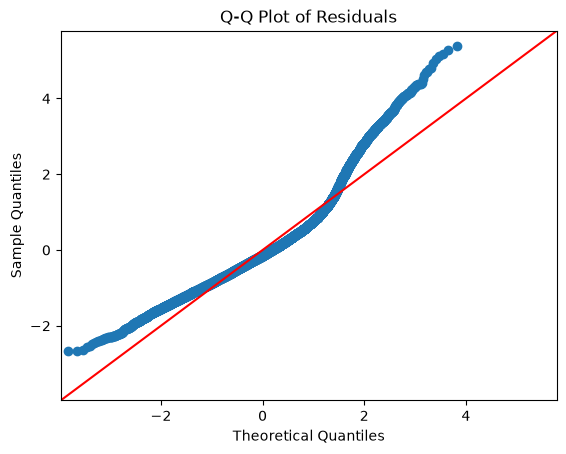

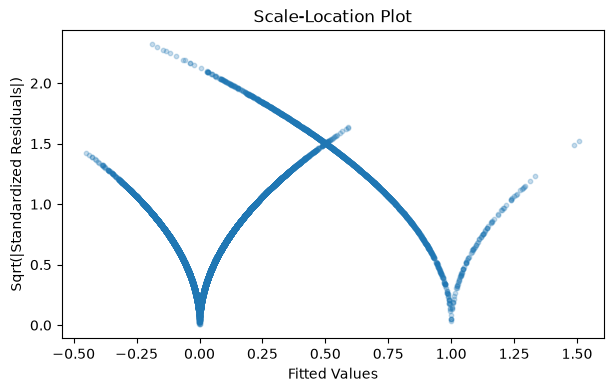

In [16]:
fitted_values = model_final.fittedvalues
residuals = model_final.resid
standardized_residuals = residuals / residuals.std(ddof=0)

# Residuals vs Fitted
plt.figure(figsize=(7, 4))
plt.scatter(fitted_values, residuals, alpha=0.25, s=10)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

# Q-Q Plot
sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Scale-Location Plot
plt.figure(figsize=(7, 4))
plt.scatter(fitted_values, np.sqrt(np.abs(standardized_residuals)), alpha=0.25, s=10)
plt.title("Scale-Location Plot")
plt.xlabel("Fitted Values")
plt.ylabel("Sqrt(|Standardized Residuals|)")
plt.show()

## 14. Diagnostic Interpretation

Write your interpretation here after running the diagnostic plots.

Suggested points:

- The residuals vs. fitted plot may show structure because the target variable is binary.
- The Q-Q plot may show non-normal residuals.
- The scale-location plot may suggest non-constant variance.
- These limitations are expected for a linear probability model.
- Week 4 logistic regression will be more appropriate for binary fault classification.

## 15. Final Regression Conclusion

The final selected model identifies the strongest determinants of Aido Rover fault status based on standardized OLS coefficients.

Expected key determinants include:

- battery state of charge
- LiDAR distance
- average wheel torque

This follows the same analytical structure as the Tsinghua rental price research project: use correlation screening, run multivariate regression, identify key determinants, and interpret the coefficients in plain English.

The main limitation is that `fault_label` is binary, so OLS should be treated as a linear probability model. Week 4 should extend this analysis using logistic regression.